# Assignment 5 – Machine Learning in R

**Author**: Casey Madison  

**Date**: 7/23/2025

**Environment**: See `environment5_R.yml`  

**Description**:  
This notebook explores basic machine learning using [scikit-learn/caret/etc.], including data preparation, model training, and evaluation.

# 1. Create a Conda Environment with R and Caret

Packages already installed in conda environment

In [2]:
# Import packages into notebook
library(ggplot2)
library(caret)
library(ellipse)
library(lattice)
library(kernlab)
library(randomForest)

# 2. Load the Data

## 2.1 Load Data the Easy Way

In [3]:
# Attach the iris dataset to the environment
data(iris)
# Rename the dataset
dataset <- iris

## 2.2 Load From CSV

In [4]:
# Define the filename
filename <- "iris.csv"
# Load the CSV file from the local directory
dataset <- read.csv(filename, header=FALSE)
# Set the column names in the dataset
colnames(dataset) <- c("Sepal.Length","Sepal.Width","Petal.Length","Petal.Width","Species")

## 2.3 Create a Validation Dataset

In [5]:
# Create a list of 80% of the rows in the original dataset we can use for training
validation_index <- createDataPartition(dataset$Species, p=0.80, list=FALSE)
# Select 20% of the data for validation
validation <- dataset[-validation_index,]
# Use the remaining 80% of data to training and testing the models
dataset <- dataset[validation_index,]

# 3. Summarize Dataset

## 3.1 Dimensions of Dataset

In [6]:
# Dimensions of dataset
dim(dataset)

[1] 120   5

## 3.2 Types of Attributes

In [7]:
# List types for each attribute
dataset$Species <- as.factor(dataset$Species)
# Returns the class (data type) of each column in the dataset
sapply(dataset, class)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width      Species 
   "numeric"    "numeric"    "numeric"    "numeric"     "factor"

## 3.3 Peek at the Data

In [8]:
# Take a peek at the first 5 rows of the data
head(dataset)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5.0,3.4,1.5,0.2,Iris-setosa


## 3.4 Levels of the Class

In [9]:
# List the levels for the class
# This is a multi-class or a multinomial classification problem (3 levels)
levels(dataset$Species)

[1] "Iris-setosa"     "Iris-versicolor" "Iris-virginica"

## 3.5 Class Distribution

In [10]:
# Summarize the class distribution
percentage <- prop.table(table(dataset$Species)) * 100
# Combines frequency and percentage of each Species into one table
cbind(freq=table(dataset$Species), percentage=percentage)

,freq,percentage
Iris-setosa,40,33.33333
Iris-versicolor,40,33.33333
Iris-virginica,40,33.33333


## 3.6 Statistical Summary

In [11]:
# Summarize attribute distributions
summary(dataset)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.100   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.400   Median :1.300  
 Mean   :5.839   Mean   :3.053   Mean   :3.758   Mean   :1.206  
 3rd Qu.:6.400   3rd Qu.:3.400   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
            Species  
 Iris-setosa    :40  
 Iris-versicolor:40  
 Iris-virginica :40  
                     
                     
                     

# 4. Visualize Dataset

## 4.1 Univariate Plots

### Box and Whisker Plots in R

In [12]:
# Split input and output
x <- dataset[, 1:4]
y <- dataset[, 5]

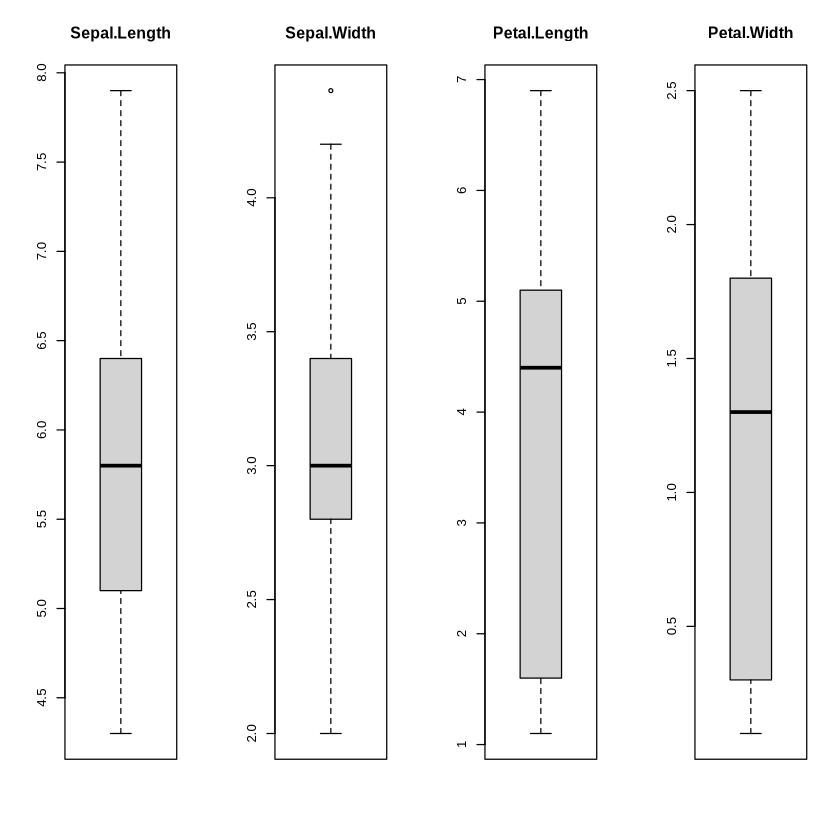

In [13]:
# Boxplot for each attribute on one image
par(mfrow=c(1,4))
  for(i in 1:4) {
  boxplot(x[,i], main=names(iris)[i])}

### Bar Plot of Iris Flower Species

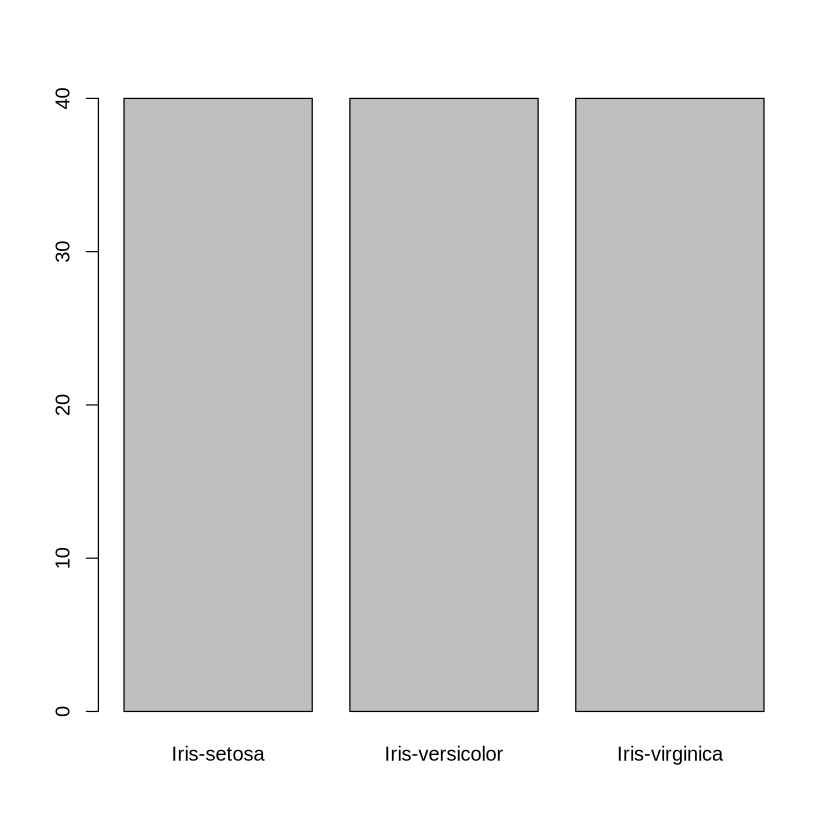

In [14]:
# Barplot for class breakdown
plot(y)

## 4.2 Multivariate Plots

### Scatterplot Matrix of Iris Data in R

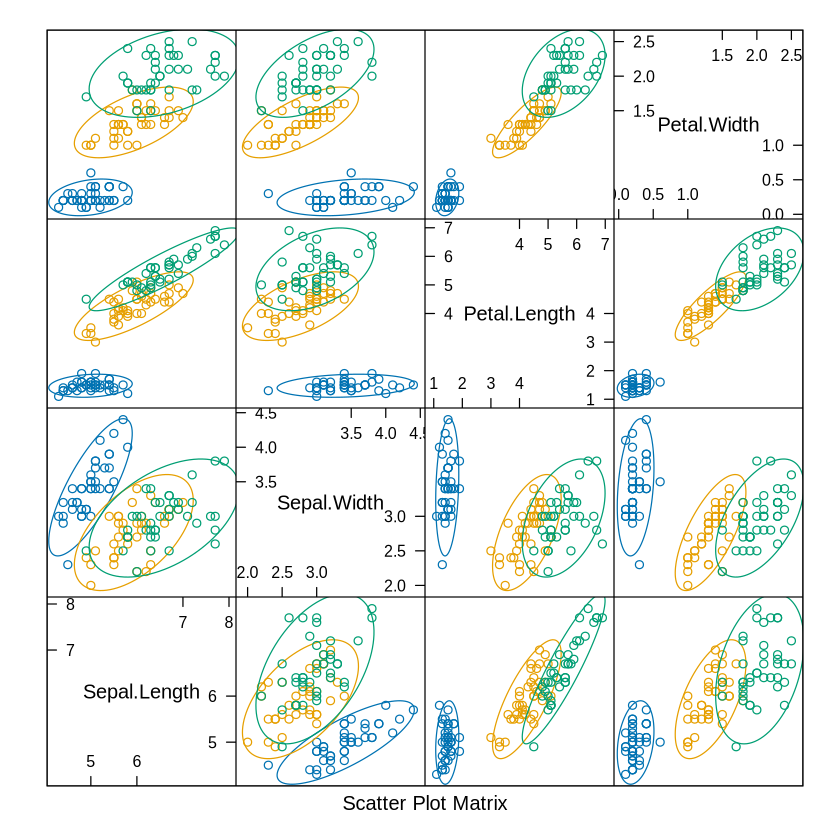

In [15]:
# Scatterplot matrix
featurePlot(x = x, y = y, plot = "ellipse")

### Box and Whisker Plot of Iris Data by Class Value

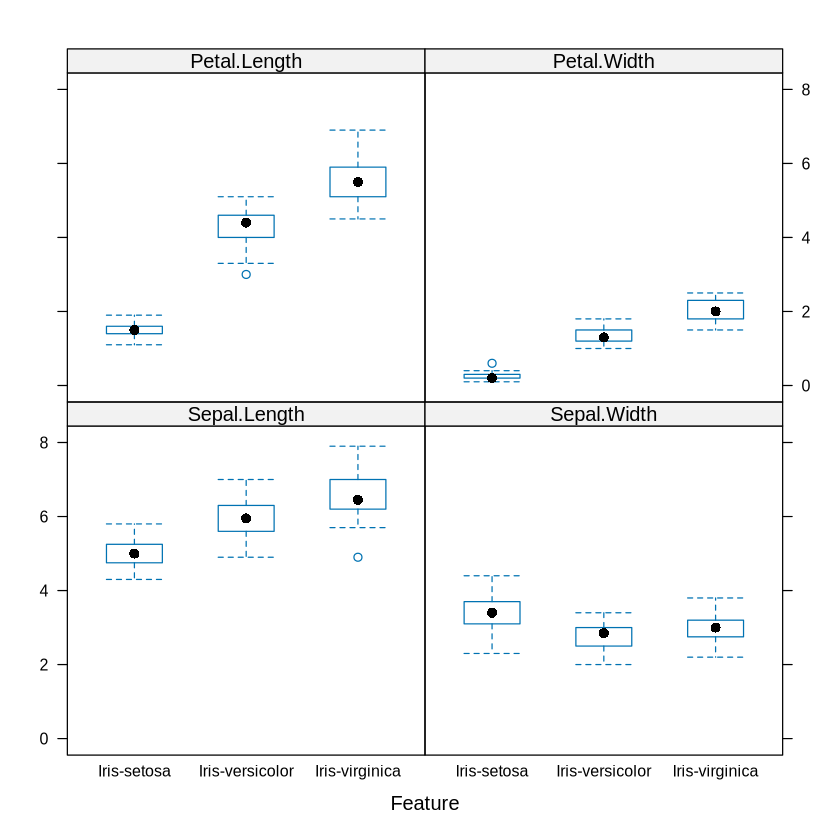

In [16]:
# Box and whisker plots for each attribute
featurePlot(x = x, y = y, plot = "box")

### Density Plots of Iris Data by Class Value

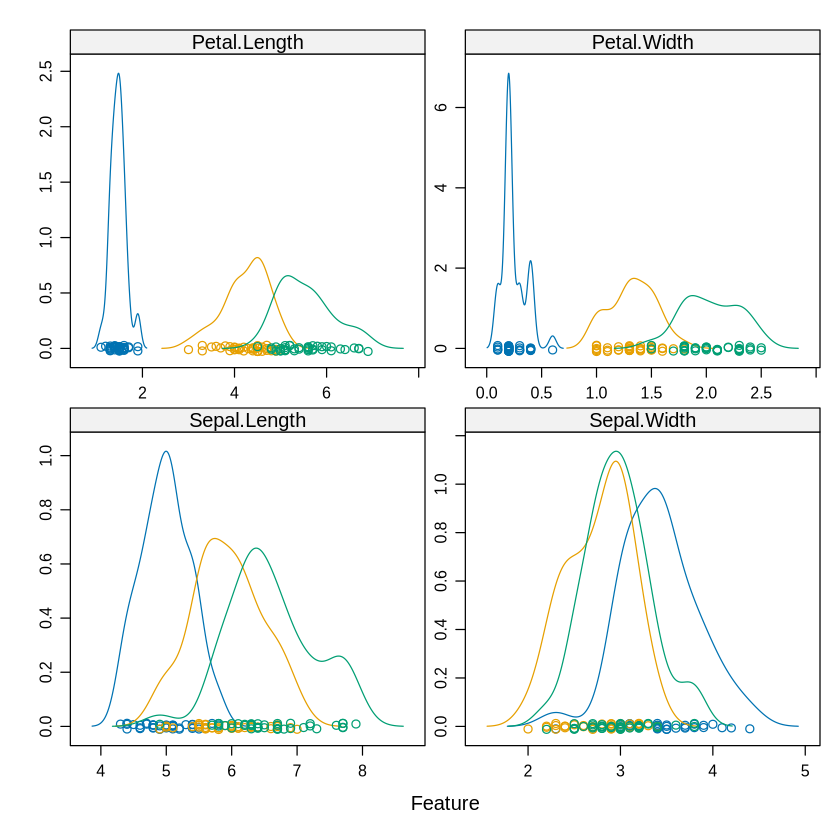

In [17]:
# Density plots for each attribute by class value
scales <- list(x = list(relation = "free"), y = list(relation = "free"))
featurePlot(x = x, y = y, plot = "density", scales = scales)

# 5. Evaluate Some Algorithms

## 5.1 Test Harness

In [18]:
# Run algorithms using 10-fold cross validation
control <- trainControl(method="cv", number=10)
metric <- "Accuracy"

## 5.2 Build Models

In [19]:
# a) Linear algorithms
set.seed(7)
fit.lda <- train(Species~., data=dataset, method="lda", metric=metric, trControl=control)
# b) Nonlinear algorithms
# CART
set.seed(7)
fit.cart <- train(Species~., data=dataset, method="rpart", metric=metric, trControl=control)
# kNN
set.seed(7)
fit.knn <- train(Species~., data=dataset, method="knn", metric=metric, trControl=control)
# c) advanced algorithms
# SVM
set.seed(7)
fit.svm <- train(Species~., data=dataset, method="svmRadial", metric=metric, trControl=control)
# Random Forest
set.seed(7)
fit.rf <- train(Species~., data=dataset, method="rf", metric=metric, trControl=control)

## 5.3 Select Best Model

In [20]:
# Summarize accuracy of models
results <- resamples(list(lda=fit.lda, cart=fit.cart, knn=fit.knn, svm=fit.svm, rf=fit.rf))
summary(results)


Call:
summary.resamples(object = results)

Models: lda, cart, knn, svm, rf 
Number of resamples: 10 

Accuracy 
          Min.   1st Qu.    Median      Mean 3rd Qu. Max. NA's
lda  0.9166667 0.9166667 1.0000000 0.9666667       1    1    0
cart 0.9166667 0.9166667 1.0000000 0.9666667       1    1    0
knn  0.8333333 0.9166667 1.0000000 0.9583333       1    1    0
svm  0.8333333 0.9166667 0.9583333 0.9500000       1    1    0
rf   0.9166667 0.9166667 0.9583333 0.9583333       1    1    0

Kappa 
      Min. 1st Qu. Median   Mean 3rd Qu. Max. NA's
lda  0.875   0.875 1.0000 0.9500       1    1    0
cart 0.875   0.875 1.0000 0.9500       1    1    0
knn  0.750   0.875 1.0000 0.9375       1    1    0
svm  0.750   0.875 0.9375 0.9250       1    1    0
rf   0.875   0.875 0.9375 0.9375       1    1    0


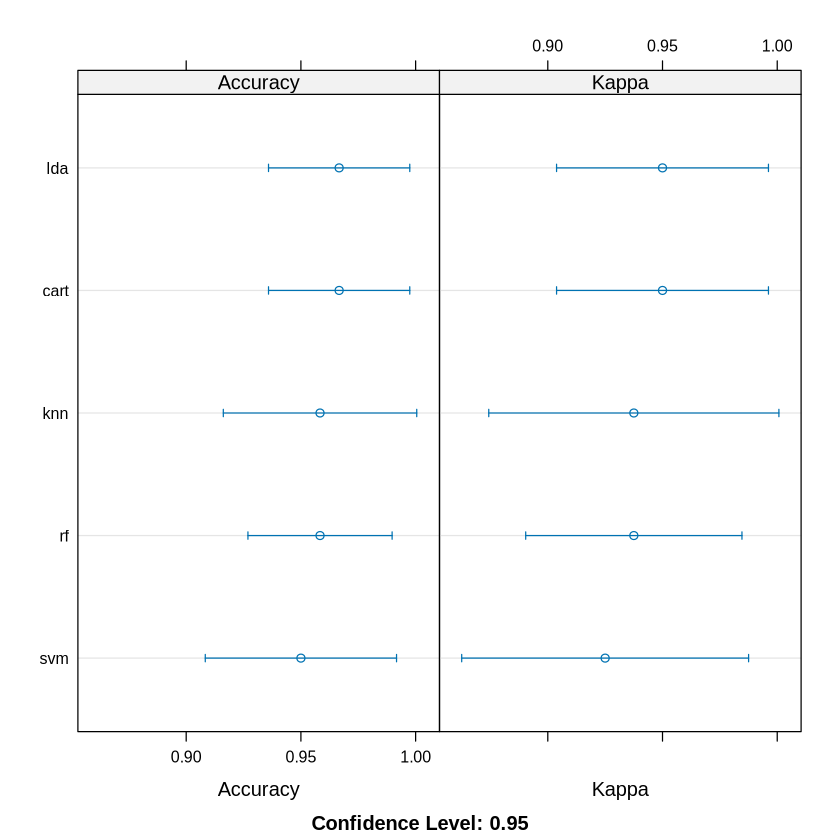

In [21]:
# Compare accuracy of models
dotplot(results)

In [22]:
# Summarize best model
print(fit.lda)

Linear Discriminant Analysis 

120 samples
  4 predictor
  3 classes: 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 108, 108, 108, 108, 108, 108, ... 
Resampling results:

  Accuracy   Kappa
  0.9666667  0.95 



In [23]:
# Another way of printing the above results, and inclusion of SD
print(fit.lda$results)

  parameter  Accuracy Kappa AccuracySD    KappaSD
1      none 0.9666667  0.95 0.04303315 0.06454972


# 6. Make Predictions

In [24]:
# Estimate skill of LDA on the validation dataset
# I had to label predictions and validation as a factor to get it to work
validation$Species <- factor(validation$Species, levels = levels(dataset$Species))
predictions <- factor(predict(fit.lda, validation), levels = levels(dataset$Species)) 
confusionMatrix(predictions, validation$Species)

Confusion Matrix and Statistics

                 Reference
Prediction        Iris-setosa Iris-versicolor Iris-virginica
  Iris-setosa              10               0              0
  Iris-versicolor           0              10              0
  Iris-virginica            0               0             10

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.8843, 1)
    No Information Rate : 0.3333     
    P-Value [Acc > NIR] : 4.857e-15  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: Iris-setosa Class: Iris-versicolor
Sensitivity                      1.0000                 1.0000
Specificity                      1.0000                 1.0000
Pos Pred Value                   1.0000                 1.0000
Neg Pred Value                   1.0000                 1.0